In [1]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()

DATABASE_URL = os.getenv("POSTGRES")

In [3]:

engine = create_engine(DATABASE_URL)

In [4]:
query = """
SELECT table_name
FROM information_schema.tables
WHERE table_schema='public'
"""

tables = pd.read_sql(query, engine)

tables

,table_name
0,properties
1,clean_properties


In [5]:
df = pd.read_sql("SELECT * FROM properties", engine)

df.head()

,id,checksum,price,location,title,beds,baths,area,property_type,furnishing,amenities,link,reactivated_date,source,scraped_at,transformed_at
0,1852,9d7a952ad16fbdf505ef4d32318945a6,13000000,"Palm Hills New Cairo Compound, 5th Settlement",None,3,3.0,173.0,Apartment,Unfurnished,"Balcony, Private Garden, Security, Pool",https://www.dubizzle.com.eg/en/ad/lowest-downp...,2026-05-11 18:32:47.811,dubizzle,2026-05-11 18:32:47.811,2026-05-11 18:33:12.590428
1,2,e1a8744d5c417095655c2fadc395a4e0,12500000,"Shubra, Cairo",None,None,NaN,200.0,Office Space,Unfurnished,"Air Conditioning, Covered Parking",https://www.dubizzle.com.eg/en/ad/for-sale-a-h...,2026-05-09 11:07:41.679,dubizzle,2026-05-09 11:07:41.680,2026-05-10 18:27:16.054129
2,1853,241fcc3c6c78c0ebd9bd2f7185831adb,3400000,"Al Andalous, 5th Settlement",None,4,3.0,202.0,Apartment,None,"Private Garden, Pool, Electricity Meter, Water...",https://www.dubizzle.com.eg/en/ad/apartment-fo...,2026-05-11 18:32:48.585,dubizzle,2026-05-11 18:32:48.585,2026-05-11 18:33:13.002106
3,4,02ac686ec68f0d48ff0f7ad6a7410057,250000,"One Katameya, Katameya",None,None,NaN,260.0,Office Space,Furnished,Air Conditioning,https://www.dubizzle.com.eg/en/ad/for-rent-an-...,2026-05-09 11:08:18.180,dubizzle,2026-05-09 11:08:18.180,2026-05-10 18:27:16.827983
4,5,9cbddb0a16e1d839fc4451eca2617920,12500000,"Shubra, Cairo",None,None,NaN,200.0,Office Space,Unfurnished,"Air Conditioning, Covered Parking",https://www.dubizzle.com.eg/en/ad/for-sale-hea...,2026-05-09 13:55:43.702,dubizzle,2026-05-09 13:55:43.702,2026-05-10 18:27:17.172836


In [6]:
df.shape

(1976, 16)

---
## Data Cleaning Pipeline

**Dataset**: Egyptian real estate listings scraped from Dubizzle and Bayut  
**Shape**: 1,976 rows × 16 columns — two sources, mixed residential and commercial listings  
**Goal**: Inspect, standardize, and flag the raw data. Missing values are preserved where they reflect genuine unknowns. No imputation, encoding, or scaling is applied here.


In [7]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

# ── Basic shape & dtypes ────────────────────────────────────────────────
print("=" * 65)
print(f"Shape: {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print("=" * 65)

print("\n── Column dtypes ──")
print(df.dtypes.to_string())

# ── Null analysis ───────────────────────────────────────────────────────
print("\n── Null counts & percentages ──")
null_summary = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_%': (df.isnull().sum() / len(df) * 100).round(1)
})
print(null_summary[null_summary['null_count'] > 0].to_string())

# ── Unique values per column ────────────────────────────────────────────
print("\n── Unique values per column ──")
for col in df.columns:
    first = df[col].dropna().iloc[0] if df[col].notna().any() else 'ALL NULL'
    print(f"  {col:<22} nunique={df[col].nunique():<6} sample={repr(str(first)[:60])}")

# ── Categorical distributions ───────────────────────────────────────────
print("\n── Categorical column distributions ──")
for col in ['property_type', 'furnishing', 'source']:
    print(f"\n  {col}:")
    print(df[col].value_counts(dropna=False).to_string(header=False))


Shape: 1,976 rows  ×  16 columns

── Column dtypes ──
id                           int64
checksum                    object
price                        int64
location                    object
title                       object
beds                        object
baths                      float64
area                       float64
property_type               object
furnishing                  object
amenities                   object
link                        object
reactivated_date    datetime64[ns]
source                      object
scraped_at          datetime64[ns]
transformed_at      datetime64[ns]

── Null counts & percentages ──
            null_count  null_%
title              209    10.6
beds                15     0.8
baths               15     0.8
furnishing         370    18.7
amenities          434    22.0

── Unique values per column ──
  id                     nunique=1976   sample='1852'
  checksum               nunique=1976   sample='9d7a952ad16fbdf505ef4d32318945a6'

## Cleaning Decisions

| Column | Issue Found | Action |
|--------|-------------|--------|
| `title` | All `None` for Dubizzle (~64% of data); Bayut populates it | Keep as optional text reference — **not used for analysis** |
| `id`, `checksum`, `link`, `scraped_at`, `transformed_at` | Internal pipeline metadata | **Drop** after deduplication |
| `reactivated_date` | Stored as string; useful recency proxy | Parse to `datetime` |
| `beds` | Float due to NaN coercion | Cast to nullable `Int64` |
| `baths` | Float — OK as-is | Keep |
| `price` | Mixed sale + rental prices (no `listing_type` column) | Flag rows < 500,000 EGP as **likely rentals** |
| `area` | Some extreme values | Flag < 20 m² as `too_small`, > 1,500 m² as `very_large` |
| `property_type` | Needs casing normalization; "Office Space" is the only commercial type | `.str.title()` + rename `Office Space` → `Commercial` |
| `furnishing` | Null for many Bayut rows; "Furnished" sometimes appears in amenities text | Backfill from amenities text where column is null |
| `location` | Dubizzle: 2 parts; Bayut: 3–4 parts with redundant city suffixes | Extract `district` (part 1) and `city` (last known city) |
| `amenities` | Comma-separated string; different vocabulary per source | Parse to Python list; compute `amenity_count` |


In [8]:
# ================================
# Basic ML Cleaning
# ================================

df_clean = df.copy()

# --------------------------------
# 1. Drop useless columns
# --------------------------------
drop_cols = [
    'title',
    'scraped_at',
]

df_clean.drop(columns=drop_cols, inplace=True)

# --------------------------------
# 2. Detect studio apartments
# --------------------------------
df_clean['is_studio'] = (
    df_clean['beds']
    .astype(str)
    .str.contains('Studio', case=False, na=False)
)

# --------------------------------
# 3. Convert Studio -> 0
# --------------------------------
df_clean['beds'] = (
    df_clean['beds']
    .replace('Studio', 0)
)

# --------------------------------
# 4. Convert beds to numeric
# --------------------------------
df_clean['beds'] = pd.to_numeric(
    df_clean['beds'],
    errors='coerce'
)

# Fill missing beds with 0
df_clean['beds'] = df_clean['beds'].fillna(0).astype(int)

# --------------------------------
# 5. Fix baths
# --------------------------------
df_clean['baths'] = pd.to_numeric(
    df_clean['baths'],
    errors='coerce'
)

df_clean['baths'] = df_clean['baths'].fillna(0)

# --------------------------------
# 6. Fix furnishing nulls
# --------------------------------
df_clean['furnishing'] = (
    df_clean['furnishing']
    .fillna('Not Specified')
)

# --------------------------------
# 7. Fix amenities nulls
# --------------------------------
df_clean['amenities'] = (
    df_clean['amenities']
    .fillna('Not Mentioned')
)

# --------------------------------
# 8. Parse transaction type
# --------------------------------
df_clean['transaction_type'] = (
    df_clean['link']
    .str.contains('for-rent', case=False, na=False)
    .map({True: 'rent', False: 'sale'})
)

# --------------------------------
# 9. Convert dates
# --------------------------------
df_clean['reactivated_date'] = pd.to_datetime(
    df_clean['reactivated_date'],
    errors='coerce'
)

# --------------------------------
# 10. Final check
# --------------------------------
print(df_clean.info())
print(df_clean.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1976 entries, 0 to 1975
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                1976 non-null   int64         
 1   checksum          1976 non-null   object        
 2   price             1976 non-null   int64         
 3   location          1976 non-null   object        
 4   beds              1976 non-null   int64         
 5   baths             1976 non-null   float64       
 6   area              1976 non-null   float64       
 7   property_type     1976 non-null   object        
 8   furnishing        1976 non-null   object        
 9   amenities         1976 non-null   object        
 10  link              1976 non-null   object        
 11  reactivated_date  1976 non-null   datetime64[ns]
 12  source            1976 non-null   object        
 13  transformed_at    1976 non-null   datetime64[ns]
 14  is_studio         1976 n

In [10]:
print(df_clean['transaction_type'].value_counts())

transaction_type
sale    1968
rent       8
Name: count, dtype: int64


In [11]:
# ==========================================
# Normalize property_type
# ==========================================

# Remove extra spaces
# Standardize text casing
# Example:
# " apartment " -> "Apartment"

df_clean['property_type'] = (
    df_clean['property_type']
    .str.strip()
    .str.title()
)

print("Normalized property_type values:\n")
print(df_clean['property_type'].value_counts())

Normalized property_type values:

property_type
Apartment            1300
Villa                 348
Townhouse             101
Duplex                 79
Twin House             46
Penthouse              39
Ivilla                 24
Office Space           10
Hotel Apartment         9
Land                    5
Studio                  4
Roof                    4
Other Residential       4
Room                    3
Name: count, dtype: int64


In [12]:
# ==========================================
# Extract district and city from location
# ==========================================

# Split location into parts
location_parts = df_clean['location'].str.split(',')

# First part → district / compound
df_clean['district'] = (
    location_parts
    .str[0]
    .str.strip()
)

# Last part → city
df_clean['city'] = (
    location_parts
    .str[-1]
    .str.strip()
)

print(df_clean[['location', 'district', 'city']].head())

                                        location  \
0  Palm Hills New Cairo Compound, 5th Settlement   
1                                  Shubra, Cairo   
2                    Al Andalous, 5th Settlement   
3                         One Katameya, Katameya   
4                                  Shubra, Cairo   

                        district            city  
0  Palm Hills New Cairo Compound  5th Settlement  
1                         Shubra           Cairo  
2                    Al Andalous  5th Settlement  
3                   One Katameya        Katameya  
4                         Shubra           Cairo  


In [13]:
# ==========================================
# Extract district and city from location
# ==========================================

KNOWN_CITIES = [
    'Cairo',
    'Giza',
    'Alexandria',
    'New Cairo',
    'New Capital City'
]

def parse_location(location):

    if pd.isna(location):
        return pd.NA, pd.NA

    parts = [p.strip() for p in location.split(',')]

    # First part usually compound / district
    district = parts[0]

    # Default
    city = 'Unknown'

    # Search for known cities
    for part in parts:
        if part in KNOWN_CITIES:
            city = part
            break

    return district, city


df_clean[['district', 'city']] = (
    df_clean['location']
    .apply(parse_location)
    .apply(pd.Series)
)

print(df_clean[['location', 'district', 'city']].head())

                                        location  \
0  Palm Hills New Cairo Compound, 5th Settlement   
1                                  Shubra, Cairo   
2                    Al Andalous, 5th Settlement   
3                         One Katameya, Katameya   
4                                  Shubra, Cairo   

                        district     city  
0  Palm Hills New Cairo Compound  Unknown  
1                         Shubra    Cairo  
2                    Al Andalous  Unknown  
3                   One Katameya  Unknown  
4                         Shubra    Cairo  


In [14]:
df_clean[['location', 'district', 'city']].head(10)

,location,district,city
0,"Palm Hills New Cairo Compound, 5th Settlement",Palm Hills New Cairo Compound,Unknown
1,"Shubra, Cairo",Shubra,Cairo
2,"Al Andalous, 5th Settlement",Al Andalous,Unknown
3,"One Katameya, Katameya",One Katameya,Unknown
4,"Shubra, Cairo",Shubra,Cairo
5,"Hyde Park New Cairo Compound, 5th Settlement",Hyde Park New Cairo Compound,Unknown
6,"Laurent, Alexandria",Laurent,Alexandria
7,"Smoha, Alexandria",Smoha,Alexandria
8,"Wesal, Shorouk City",Wesal,Unknown
9,"Reve du nil, Maadi",Reve du nil,Unknown


In [15]:
# ==========================================
# Explore all location parts
# ==========================================

all_parts = []

for loc in df_clean['location'].dropna():

    parts = [p.strip() for p in loc.split(',')]

    all_parts.extend(parts)

parts_series = pd.Series(all_parts)

print(parts_series.value_counts().head(100))

Cairo                              1807
New Cairo                           922
5th Settlement                      764
Madinaty                            232
New Capital City                    168
                                   ... 
Tag Sultan Compound                   5
Gharb Golf & Extension Compound       5
Sarayat El Katameya                   5
De Joya 4                             5
Hyde Park Central                     5
Name: count, Length: 100, dtype: int64


In [16]:
# ==========================================
# Extract district and location group
# ==========================================

location_parts = df_clean['location'].str.split(',')

# First part → compound / district
df_clean['district'] = (
    location_parts
    .str[0]
    .str.strip()
)

# Last part → broader location group
df_clean['location_group'] = (
    location_parts
    .str[-1]
    .str.strip()
)

print(df_clean[['location', 'district', 'location_group']].head(10))

                                        location  \
0  Palm Hills New Cairo Compound, 5th Settlement   
1                                  Shubra, Cairo   
2                    Al Andalous, 5th Settlement   
3                         One Katameya, Katameya   
4                                  Shubra, Cairo   
5   Hyde Park New Cairo Compound, 5th Settlement   
6                            Laurent, Alexandria   
7                              Smoha, Alexandria   
8                            Wesal, Shorouk City   
9                             Reve du nil, Maadi   

                        district  location_group  
0  Palm Hills New Cairo Compound  5th Settlement  
1                         Shubra           Cairo  
2                    Al Andalous  5th Settlement  
3                   One Katameya        Katameya  
4                         Shubra           Cairo  
5   Hyde Park New Cairo Compound  5th Settlement  
6                        Laurent      Alexandria  
7                  

In [17]:
# ── Parse amenities to list + count ────────────────────────────────────
#
# Why NOT unify vocabulary here:
#   Dubizzle uses short labels  →  "Balcony", "Pool", "Security"
#   Bayut uses verbose phrases  →  "Balcony or Terrace", "Swimming Pool",
#                                  "CCTV Security", "Kids Play Area"
#
# Mapping them to a shared vocabulary requires human judgment about which
# Bayut phrases match which Dubizzle labels — that is ML preprocessing.
# For now we parse each row into a Python list and compute a count.
# ==========================================
# Parse amenities into list + count
# ==========================================

def parse_amenities(text):

    if pd.isna(text) or text == 'Not Mentioned':
        return []

    return [
        item.strip()
        for item in str(text).split(',')
        if item.strip()
    ]

# Convert amenities string -> list
df_clean['amenities_list'] = (
    df_clean['amenities']
    .apply(parse_amenities)
)

# Count amenities
df_clean['amenity_count'] = (
    df_clean['amenities_list']
    .apply(len)
)

print(df_clean[['amenities', 'amenities_list', 'amenity_count']].head())

                                           amenities  \
0            Balcony, Private Garden, Security, Pool   
1                  Air Conditioning, Covered Parking   
2  Private Garden, Pool, Electricity Meter, Water...   
3                                   Air Conditioning   
4                  Air Conditioning, Covered Parking   

                                      amenities_list  amenity_count  
0          [Balcony, Private Garden, Security, Pool]              4  
1                [Air Conditioning, Covered Parking]              2  
2  [Private Garden, Pool, Electricity Meter, Wate...              5  
3                                 [Air Conditioning]              1  
4                [Air Conditioning, Covered Parking]              2  


In [18]:
all_amenities = []

for row in df_clean['amenities_list']:
    all_amenities.extend(row)

unique_amenities = pd.Series(all_amenities)

print(unique_amenities.value_counts().head(200))

Electricity Meter           1045
Water Meter                  942
Natural Gas                  935
Security Staff               908
Lawn or Garden               889
                            ... 
Parking Spaces: 43             1
Elevators in Building: 3       1
Total Floors: 12               1
Parking Spaces: 10             1
Elevators in Building: 4       1
Name: count, Length: 95, dtype: int64


In [20]:
# ==========================================
# Show amenities for each source
# ==========================================

for source_name in df_clean['source'].unique():

    all_amenities = []

    source_rows = df_clean.loc[
        df_clean['source'] == source_name,
        'amenities_list'
    ]

    for row in source_rows:
        all_amenities.extend(row)

    amenities_series = pd.Series(all_amenities)

    print("\n" + "=" * 60)
    print(f"Amenities — {source_name}")
    print("=" * 60)

    print(
        amenities_series
        .value_counts()
        .head(100)
    )


Amenities — dubizzle
Security                       100
Private Garden                  96
Electricity Meter               94
Balcony                         88
Covered Parking                 87
Natural Gas                     78
Water Meter                     77
Pets Allowed                    76
Landline                        70
Pool                            61
Built in Kitchen Appliances     41
Elevator                        27
Central A/C & heating           19
Maids Room                      12
Air Conditioning                 3
Name: count, dtype: int64

Amenities — bayut
Electricity Meter           951
Security Staff              908
Lawn or Garden              889
Covered parking             877
Water Meter                 865
                           ... 
Parking Spaces: 43            1
Elevators in Building: 3      1
Total Floors: 12              1
Parking Spaces: 10            1
Elevators in Building: 4      1
Name: count, Length: 88, dtype: int64


In [21]:
# ==========================================
# Create price per sqm
# ==========================================

df_clean['price_per_sqm'] = (
    df_clean['price'] / df_clean['area']
)

print(df_clean[['price', 'area', 'price_per_sqm']].head())

      price   area  price_per_sqm
0  13000000  173.0   75144.508671
1  12500000  200.0   62500.000000
2   3400000  202.0   16831.683168
3    250000  260.0     961.538462
4  12500000  200.0   62500.000000


In [22]:
# ==========================================
# Final Dataset Inspection
# ==========================================

print("=" * 70)
print("FINAL CLEANED DATASET OVERVIEW")
print("=" * 70)

# ------------------------------------------
# Shape
# ------------------------------------------
print(f"\nShape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")

# ------------------------------------------
# Dtypes
# ------------------------------------------
print("\n=== Column Data Types ===")
print(df_clean.dtypes.to_string())

# ------------------------------------------
# Null values
# ------------------------------------------
print("\n=== Null Values ===")

nulls = pd.DataFrame({
    'null_count': df_clean.isnull().sum(),
    'null_percentage': (
        df_clean.isnull().sum() / len(df_clean) * 100
    ).round(2)
})

print(
    nulls[nulls['null_count'] > 0]
    .sort_values(by='null_count', ascending=False)
)

# ------------------------------------------
# Numeric summary
# ------------------------------------------
print("\n=== Numeric Summary ===")

print(
    df_clean.describe().round(2)
)

# ------------------------------------------
# Property types
# ------------------------------------------
print("\n=== Property Types ===")

print(
    df_clean['property_type']
    .value_counts()
)

# ------------------------------------------
# Transaction types
# ------------------------------------------
print("\n=== Transaction Types ===")

print(
    df_clean['transaction_type']
    .value_counts()
)

# ------------------------------------------
# Furnishing
# ------------------------------------------
print("\n=== Furnishing ===")

print(
    df_clean['furnishing']
    .value_counts()
)

# ------------------------------------------
# Top districts
# ------------------------------------------
print("\n=== Top Districts ===")

print(
    df_clean['district']
    .value_counts()
    .head(15)
)

# ------------------------------------------
# Amenities count
# ------------------------------------------
print("\n=== Amenity Count Statistics ===")

print(
    df_clean['amenity_count']
    .describe()
)

# ------------------------------------------
# Preview
# ------------------------------------------
print("\n=== Dataset Preview ===")

print(df_clean.head())

FINAL CLEANED DATASET OVERVIEW

Shape: 1,976 rows × 22 columns

=== Column Data Types ===
id                           int64
checksum                    object
price                        int64
location                    object
beds                         int64
baths                      float64
area                       float64
property_type               object
furnishing                  object
amenities                   object
link                        object
reactivated_date    datetime64[ns]
source                      object
transformed_at      datetime64[ns]
is_studio                     bool
transaction_type            object
district                    object
city                        object
location_group              object
amenities_list              object
amenity_count                int64
price_per_sqm              float64

=== Null Values ===
Empty DataFrame
Columns: [null_count, null_percentage]
Index: []

=== Numeric Summary ===
            id         price 

---
## Exploratory Data Analysis


Null percentages in cleaned dataset:

Empty DataFrame
Columns: [null_%, count]
Index: []


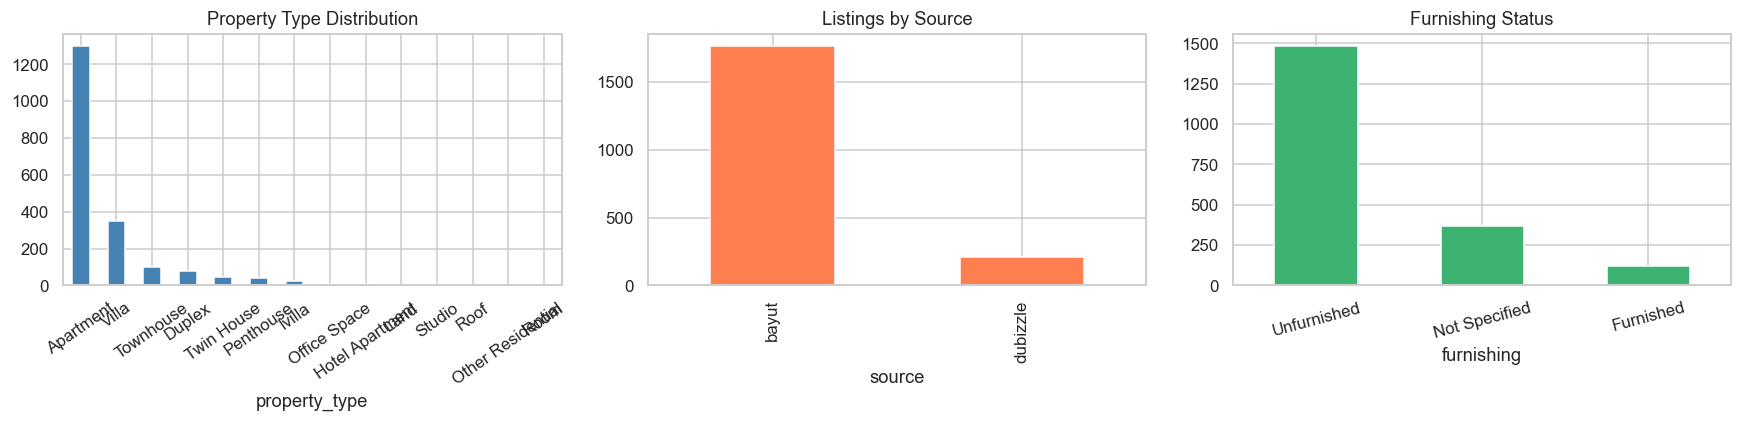


Sale listings count: 1,968

Price Statistics (EGP):

count         1968.0
mean      14256422.0
std       18380439.0
min         800000.0
25%        5622750.0
50%        9000000.0
75%       16000000.0
max      312000000.0
Name: price, dtype: float64

Median price per m²: 54,078 EGP/m²
Mean   price per m²: 60,732 EGP/m²


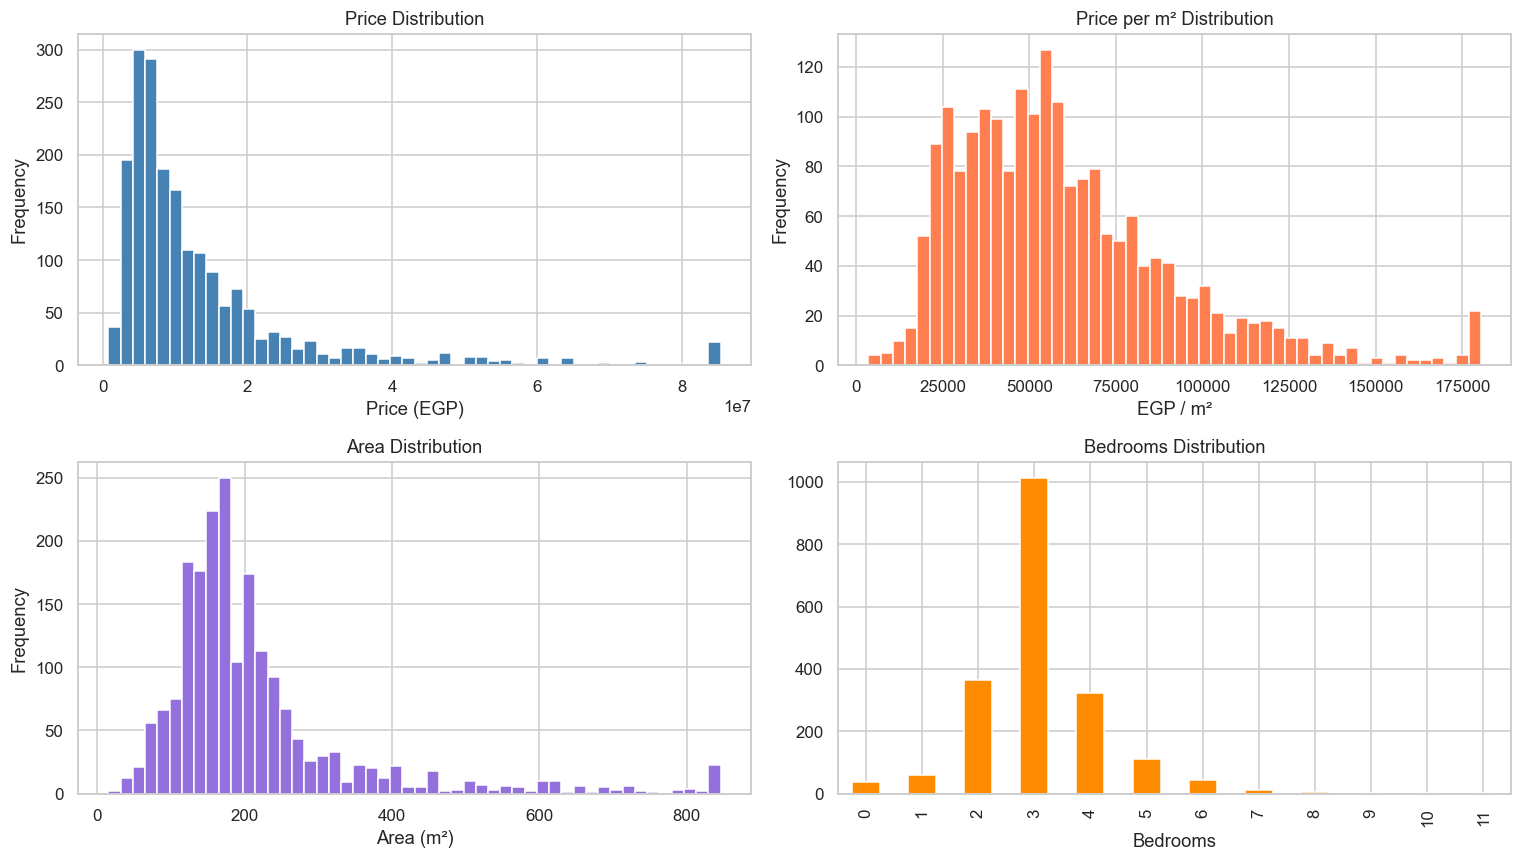

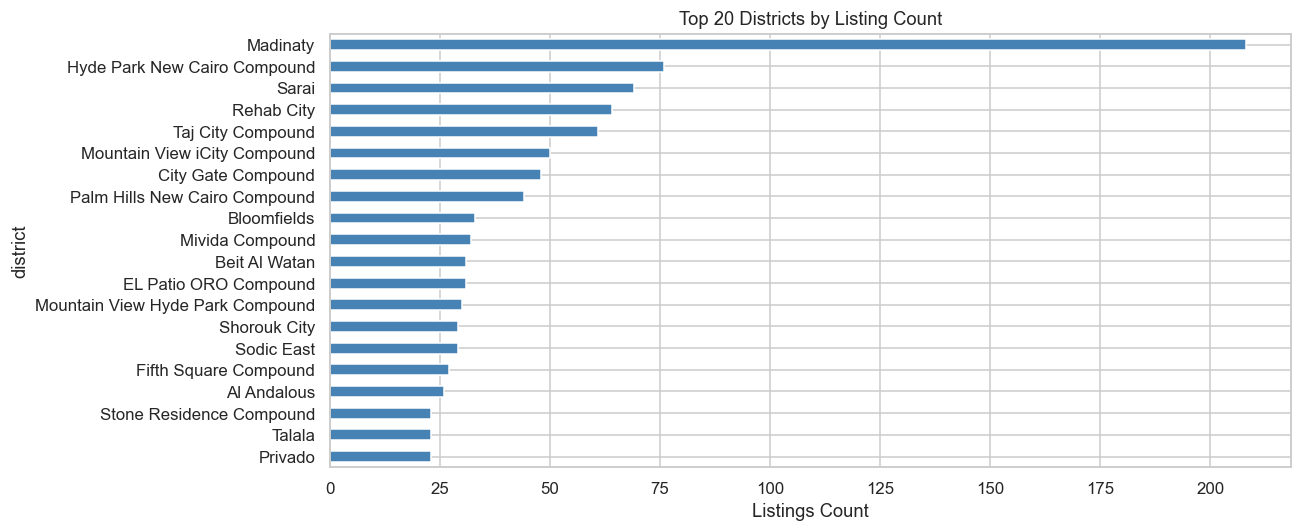


Median Sale Price by Property Type:

                       median  count
property_type                       
Room                4064000.0      3
Studio              4337200.0      4
Roof                5950000.0      4
Apartment           6700000.0   1300
Hotel Apartment     7640000.0      9
Duplex              9442832.0     79
Other Residential  10800000.0      4
Ivilla             11069500.0     24
Office Space       12500000.0      2
Penthouse          12800000.0     39
Land               16500000.0      5
Townhouse          18000000.0    101
Villa              24950000.0    348
Twin House         27850000.0     46


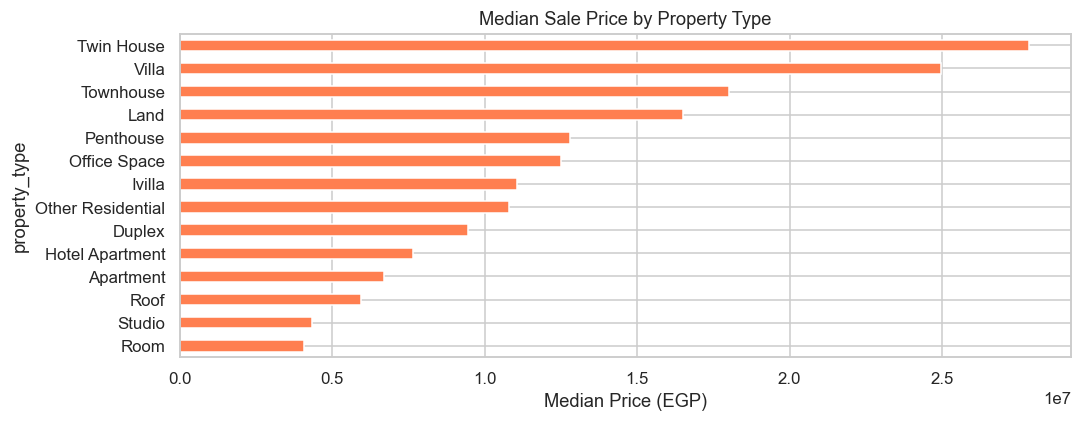

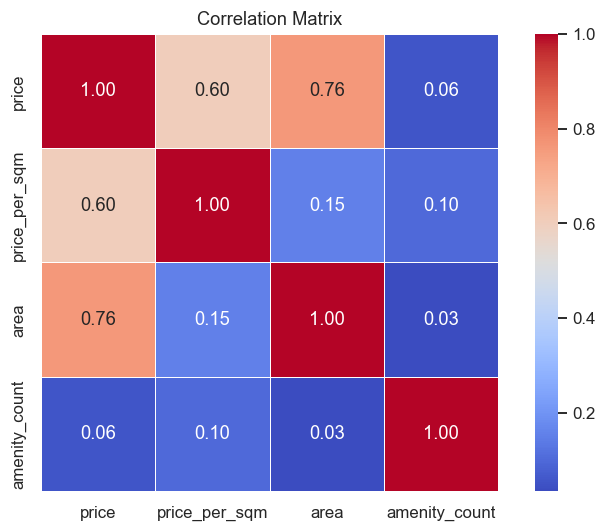


=== Top 10 Most Expensive Listings ===

    price  price_per_sqm property_type  beds   area                district source
312000000  124800.000000         Villa    11 2500.0 Katameya Dunes Compound  bayut
234000000  124468.085106         Villa    10 1880.0 Katameya Dunes Compound  bayut
190000000  146153.846154         Villa     8 1300.0            Uptown Cairo  bayut
185000000  259103.641457         Villa     5  714.0      City Gate Compound  bayut
185000000  259103.641457         Villa     5  714.0      City Gate Compound  bayut
145000000  120833.333333         Villa     7 1200.0 Katameya Dunes Compound  bayut
139970000  247734.513274         Villa     4  565.0      City Gate Compound  bayut
139970000  247734.513274         Villa     4  565.0      City Gate Compound  bayut
130000000  130000.000000         Villa     5 1000.0     Cairo Festival City  bayut
125000000  250000.000000         Villa     7  500.0         Mivida Compound  bayut

=== Lowest Price per m² Listings ===

  price

In [24]:
# ==========================================
# EDA 1 — Missing Values Overview
# ==========================================
# الهدف:
# نشوف هل لسه فيه null values بعد الـ cleaning
# ونسبتها كام في كل عمود

null_pct = (
    df_clean.isnull().sum() / len(df_clean) * 100
).round(1)

null_table = pd.DataFrame({
    'null_%': null_pct,
    'count': df_clean.isnull().sum()
})

null_table = (
    null_table[null_table['count'] > 0]
    .sort_values(by='null_%', ascending=False)
)

print("Null percentages in cleaned dataset:\n")
print(null_table)


# ==========================================
# EDA 2 — Basic Categorical Distributions
# ==========================================
# الهدف:
# نفهم توزيع:
# - أنواع العقارات
# - مصادر البيانات
# - حالة الفرش

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Property types
df_clean['property_type'].value_counts().plot.bar(
    ax=axes[0],
    color='steelblue',
    edgecolor='white'
)
axes[0].set_title('Property Type Distribution')
axes[0].tick_params(axis='x', rotation=35)

# Sources
df_clean['source'].value_counts().plot.bar(
    ax=axes[1],
    color='coral',
    edgecolor='white'
)
axes[1].set_title('Listings by Source')

# Furnishing
df_clean['furnishing'].value_counts().plot.bar(
    ax=axes[2],
    color='mediumseagreen',
    edgecolor='white'
)
axes[2].set_title('Furnishing Status')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


# ==========================================
# EDA 3 — Sale Listings Statistics
# ==========================================
# الهدف:
# تحليل أسعار العقارات المعروضة للبيع فقط

sale_df = df_clean[
    df_clean['transaction_type'] == 'sale'
].copy()

print(f"\nSale listings count: {len(sale_df):,}")

print("\nPrice Statistics (EGP):\n")
print(
    sale_df['price']
    .describe()
    .round(0)
)

print(f"\nMedian price per m²: {sale_df['price_per_sqm'].median():,.0f} EGP/m²")
print(f"Mean   price per m²: {sale_df['price_per_sqm'].mean():,.0f} EGP/m²")


# ==========================================
# EDA 4 — Numerical Distributions
# ==========================================
# الهدف:
# فهم شكل توزيع:
# - الأسعار
# - سعر المتر
# - المساحات
# - عدد الغرف

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Price distribution
p99_price = sale_df['price'].quantile(0.99)

sale_df['price'].clip(
    upper=p99_price
).plot.hist(
    bins=50,
    ax=axes[0, 0],
    color='steelblue',
    edgecolor='white'
)

axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price (EGP)')


# Price per sqm
p99_ppsm = sale_df['price_per_sqm'].quantile(0.99)

sale_df['price_per_sqm'].clip(
    upper=p99_ppsm
).plot.hist(
    bins=50,
    ax=axes[0, 1],
    color='coral',
    edgecolor='white'
)

axes[0, 1].set_title('Price per m² Distribution')
axes[0, 1].set_xlabel('EGP / m²')


# Area distribution
p99_area = df_clean['area'].quantile(0.99)

df_clean['area'].clip(
    upper=p99_area
).plot.hist(
    bins=50,
    ax=axes[1, 0],
    color='mediumpurple',
    edgecolor='white'
)

axes[1, 0].set_title('Area Distribution')
axes[1, 0].set_xlabel('Area (m²)')


# Bedrooms distribution
df_clean['beds'].value_counts().sort_index().plot.bar(
    ax=axes[1, 1],
    color='darkorange',
    edgecolor='white'
)

axes[1, 1].set_title('Bedrooms Distribution')
axes[1, 1].set_xlabel('Bedrooms')

plt.tight_layout()
plt.show()


# ==========================================
# EDA 5 — Top Districts
# ==========================================
# الهدف:
# معرفة أكثر المناطق ظهورًا في البيانات

fig, ax = plt.subplots(figsize=(12, 5))

df_clean['district'].value_counts().head(20).sort_values().plot.barh(
    ax=ax,
    color='steelblue',
    edgecolor='white'
)

ax.set_title('Top 20 Districts by Listing Count')
ax.set_xlabel('Listings Count')

plt.tight_layout()
plt.show()


# ==========================================
# EDA 6 — Median Price by Property Type
# ==========================================
# الهدف:
# مقارنة متوسط أسعار أنواع العقارات المختلفة

price_by_type = (
    sale_df.groupby('property_type')['price']
    .agg(['median', 'count'])
    .sort_values('median')
)

print("\nMedian Sale Price by Property Type:\n")
print(price_by_type)

fig, ax = plt.subplots(figsize=(10, 4))

price_by_type['median'].plot.barh(
    ax=ax,
    color='coral',
    edgecolor='white'
)

ax.set_title('Median Sale Price by Property Type')
ax.set_xlabel('Median Price (EGP)')

plt.tight_layout()
plt.show()


# ==========================================
# EDA 7 — Correlation Heatmap
# ==========================================
# الهدف:
# قياس العلاقة بين أهم المتغيرات الرقمية

num_cols = [
    'price',
    'price_per_sqm',
    'area',
    'amenity_count'
]

corr = sale_df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True,
    ax=ax
)

ax.set_title('Correlation Matrix')

plt.tight_layout()
plt.show()


# ==========================================
# EDA 8 — Extreme Listings
# ==========================================
# الهدف:
# استكشاف العقارات الأغلى والأرخص بالنسبة لسعر المتر

print("\n=== Top 10 Most Expensive Listings ===\n")

top10 = sale_df.nlargest(10, 'price')[
    [
        'price',
        'price_per_sqm',
        'property_type',
        'beds',
        'area',
        'district',
        'source'
    ]
]

print(top10.to_string(index=False))


print("\n=== Lowest Price per m² Listings ===\n")

cheap = sale_df[
    sale_df['area'] >= 50
].nsmallest(10, 'price_per_sqm')

print(
    cheap[
        [
            'price',
            'price_per_sqm',
            'property_type',
            'beds',
            'area',
            'district'
        ]
    ].to_string(index=False)
)

In [ ]:

# ── EDA 1: Null percentages ─────────────────────────────────────────────
null_pct = (df_clean.isnull().sum() / len(df_clean) * 100).round(1).sort_values(ascending=False)
null_table = null_pct[null_pct > 0].rename('null_%').to_frame()
null_table['count'] = df_clean.isnull().sum()[null_table.index]
print("Null percentages in clean DataFrame:")
print(null_table.to_string())

# ── EDA 2: Property type + source + furnishing ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_clean['property_type'].value_counts().plot.bar(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Property Type Counts'); axes[0].tick_params(axis='x', rotation=35)

df_clean['source'].value_counts().plot.bar(ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Listings by Source'); axes[1].tick_params(axis='x', rotation=0)

df_clean['furnishing'].value_counts(dropna=False).plot.bar(ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Furnishing Status'); axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()

# ── EDA 3: Price statistics ─────────────────────────────────────────────
sale_df = df_clean[df_clean['price_flag'] == 'ok'].copy()
print(f"\nSale listings: {len(sale_df):,}")
print("\nPrice statistics (EGP):")
print(sale_df['price'].describe().apply(lambda x: f"{x:>15,.0f}"))
print(f"\nMedian price/m²:  {sale_df['price_per_sqm'].median():,.0f} EGP/m²")
print(f"Mean   price/m²:  {sale_df['price_per_sqm'].mean():,.0f} EGP/m²")

# ── EDA 4: Distributions ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

p99_price = sale_df['price'].quantile(0.99)
sale_df['price'].clip(upper=p99_price).plot.hist(
    bins=50, ax=axes[0, 0], color='steelblue', edgecolor='white')
axes[0, 0].set_title('Price Distribution (clipped at 99th pct)')
axes[0, 0].set_xlabel('Price (EGP)')

p99_ppsm = sale_df['price_per_sqm'].quantile(0.99)
sale_df['price_per_sqm'].clip(upper=p99_ppsm).plot.hist(
    bins=50, ax=axes[0, 1], color='coral', edgecolor='white')
axes[0, 1].set_title('Price per m² Distribution (clipped at 99th pct)')
axes[0, 1].set_xlabel('EGP / m²')

p99_area = df_clean['area'].quantile(0.99)
df_clean['area'].clip(upper=p99_area).plot.hist(
    bins=50, ax=axes[1, 0], color='mediumpurple', edgecolor='white')
axes[1, 0].set_title('Area Distribution (m²)')
axes[1, 0].set_xlabel('Area (m²)')

df_clean['beds'].value_counts(dropna=True).sort_index().plot.bar(
    ax=axes[1, 1], color='darkorange', edgecolor='white')
axes[1, 1].set_title('Beds Distribution')
axes[1, 1].set_xlabel('Bedrooms')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()

# ── EDA 5: Top 20 districts ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
df_clean['district'].value_counts().head(20).sort_values().plot.barh(
    ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Districts by Listing Count')
ax.set_xlabel('Count')
plt.tight_layout(); plt.show()

# ── EDA 6: Median price by property type ────────────────────────────────
price_by_type = (
    sale_df.groupby('property_type')['price']
    .agg(['median', 'count'])
    .sort_values('median')
)
print("\nMedian sale price by property type:")
print(price_by_type.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
price_by_type['median'].plot.barh(ax=ax, color='coral', edgecolor='white')
ax.set_title('Median Sale Price by Property Type (EGP)')
ax.set_xlabel('Median Price (EGP)')
plt.tight_layout(); plt.show()

# ── EDA 7: Correlation heatmap ───────────────────────────────────────────
num_cols = ['price', 'price_per_sqm', 'area', 'amenity_count']
num_cols = [c for c in num_cols if c in sale_df.columns]
corr = sale_df[num_cols].apply(pd.to_numeric, errors='coerce').corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, ax=ax)
ax.set_title('Correlation Matrix (residential sale listings)')
plt.tight_layout(); plt.show()

# ── EDA 8: Outlier summary ───────────────────────────────────────────────
print("\n── Top 10 most expensive listings ──")
top10 = sale_df.nlargest(10, 'price')[
    ['price', 'price_per_sqm', 'property_type', 'beds', 'area', 'district', 'source']
]
print(top10.to_string(index=False))

print("\n── Lowest price/m² (area ≥ 50 m², sale only) ──")
cheap = sale_df[sale_df['area'] >= 50].nsmallest(10, 'price_per_sqm')
print(cheap[['price', 'price_per_sqm', 'property_type', 'beds', 'area', 'district']].to_string(index=False))

print(f"\n── Likely-rental listings: {(df_clean['price_flag'] == 'likely_rental').sum()} ──")
rental_df = df_clean[df_clean['price_flag'] == 'likely_rental']
print(rental_df[['price', 'property_type', 'area', 'district']].describe().round(0))


---
## ML Readiness Audit

A systematic review of `df_clean` from a machine learning perspective.  
Each section flags what is **good**, what is a **risk**, and what still needs work before modeling.


In [ ]:

import warnings
warnings.filterwarnings('ignore')

SEP = "=" * 65
SEC = "─" * 65

# ══════════════════════════════════════════════════════════════════
# AUDIT 1 — Dataset snapshot
# ══════════════════════════════════════════════════════════════════
print(SEP)
print("AUDIT 1 — DATASET SNAPSHOT")
print(SEP)
print(f"  Rows    : {len(df_clean):,}")
print(f"  Columns : {df_clean.shape[1]}")
print(f"  Source split:")
print(df_clean['source'].value_counts().to_string())

# ── Deduplication check ────────────────────────────────────────────
n_checksum_dupes = df_clean['checksum'].duplicated().sum()
n_structural_dupes = df_clean.duplicated(subset=['price', 'area', 'beds', 'location']).sum()
print(f"\n  [RISK] Duplicate rows (by checksum)              : {n_checksum_dupes}")
print(f"  [RISK] Structural near-dupes (price+area+beds+loc): {n_structural_dupes}")
if n_checksum_dupes > 0 or n_structural_dupes > 0:
    print("  → Dataset was NOT deduplicated. Same listing may train and test simultaneously.")

# ══════════════════════════════════════════════════════════════════
# AUDIT 2 — Null values
# ══════════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("AUDIT 2 — NULL VALUES")
print(SEP)
null_counts = df_clean.isnull().sum()
has_nulls = null_counts[null_counts > 0]
if has_nulls.empty:
    print("  No null values — BUT check whether nulls were imputed vs genuinely absent.")
    print("  Imputed-to-zero beds/baths hides missing data from the model.")
else:
    print(has_nulls.to_string())

# beds=0 check: residential with 0 beds is suspicious
res_mask = ~df_clean['property_type'].isin(['Office Space', 'Commercial', 'Land', 'Other Residential'])
zero_beds_res = ((df_clean['beds'] == 0) & res_mask).sum()
zero_baths_res = ((df_clean['baths'] == 0) & res_mask).sum()
print(f"\n  [RISK] Residential rows with beds==0  : {zero_beds_res}")
print(f"  [RISK] Residential rows with baths==0 : {zero_baths_res}")
print("  → beds/baths nulls were imputed to 0. Model will treat 'missing' as '0 bedrooms'.")
print("    Prefer a missing-indicator column + median imputation in preprocessing.")

# ══════════════════════════════════════════════════════════════════
# AUDIT 3 — Data type correctness
# ══════════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("AUDIT 3 — DATA TYPES")
print(SEP)
print(df_clean.dtypes.to_string())

non_feature_cols = ['id', 'checksum', 'link', 'transformed_at',
                    'amenities', 'amenities_list', 'location', 'city']
still_present = [c for c in non_feature_cols if c in df_clean.columns]
print(f"\n  [RISK] Columns that must be dropped before modeling:")
for c in still_present:
    print(f"    • {c}")

list_cols = [c for c in df_clean.columns if df_clean[c].apply(type).eq(list).any()]
print(f"\n  [RISK] Python list-typed columns (not sklearn-compatible): {list_cols}")

# ══════════════════════════════════════════════════════════════════
# AUDIT 4 — Target variable & leakage
# ══════════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("AUDIT 4 — TARGET VARIABLE & LEAKAGE RISKS")
print(SEP)
print("  Assumed target: price (sale price in EGP)")
print()

leakage_cols = {
    'price_per_sqm' : 'Computed as price/area — direct algebraic function of the target.',
    'price_flag'    : 'Derived from price via pd.cut — encodes the target value range.',
    'price_outlier' : 'Boolean derived from price IQR — encodes target distribution info.',
}
for col, reason in leakage_cols.items():
    present = col in df_clean.columns
    tag = '[LEAK]' if present else '[OK — absent]'
    print(f"  {tag} {col}: {reason}")

print()
print("  [RISK] transaction_type column:")
print(f"    • 'sale' count : {(df_clean['transaction_type']=='sale').sum()}")
print(f"    • 'rent' count : {(df_clean['transaction_type']=='rent').sum()}")
cheap_mask = df_clean['price'] < 500_000
print(f"    • Rows with price < 500,000 EGP: {cheap_mask.sum()} (likely rentals, priced in EGP/month)")
print("    → URL-based detection caught only 8 rentals. Hundreds of rental listings")
print("      remain labelled 'sale'. Mixing sale and rental prices will badly distort")
print("      any price prediction model.")

# ══════════════════════════════════════════════════════════════════
# AUDIT 5 — Categorical consistency
# ══════════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("AUDIT 5 — CATEGORICAL CONSISTENCY")
print(SEP)

print("  property_type:")
pt_counts = df_clean['property_type'].value_counts(dropna=False)
print(pt_counts.to_string())
rare_types = pt_counts[pt_counts < 10]
print(f"\n  [RISK] Rare property types (< 10 rows) that will hurt encoding:")
print(f"    {rare_types.index.tolist()}")
print("    → 'Ivilla' is a mis-cased variant of 'iVilla'. Should be merged with 'Villa'.")
print("    → 'Land', 'Room', 'Other Residential' have 3–5 rows — group into 'Other'.")

print("\n  furnishing:")
print(df_clean['furnishing'].value_counts(dropna=False).to_string())
print("  [RISK] 'Not Specified' is an imputed category, not a real furnishing state.")
print("    It will be one-hot encoded as a real category, silently inflating dimensionality.")
print("    Better approach: keep as null, add a binary 'furnishing_known' flag instead.")

print("\n  is_studio:")
print(f"    True count : {df_clean['is_studio'].sum()}")
print(f"    False count: {(~df_clean['is_studio']).sum()}")
print("  [RISK] is_studio is always False — the beds column was already numeric when")
print("    the string check ran. The column carries no signal.")

# ══════════════════════════════════════════════════════════════════
# AUDIT 6 — Location quality
# ══════════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("AUDIT 6 — LOCATION QUALITY")
print(SEP)

print(f"  Unique districts: {df_clean['district'].nunique()}")
print(f"  Unique cities   : {df_clean['city'].nunique()}")

unknown_city = (df_clean['city'] == 'Unknown').sum()
print(f"\n  [RISK] Rows where city == 'Unknown': {unknown_city} "
      f"({unknown_city/len(df_clean)*100:.1f}%)")
print("    → Dubizzle location format is 'Compound, District' — no city token.")
print("      The parser correctly returned Unknown for these rows, but Unknown")
print("      will be encoded as a real city label, corrupting the location feature.")

print(f"\n  location_group (last comma-token):")
print(df_clean['location_group'].value_counts().head(15).to_string())
print("  [OK] location_group is a better area grouping than city for this dataset.")
print("       '5th Settlement', 'Cairo', 'Madinaty' are all meaningful groups.")
print("       High cardinality (250+ districts) → will need target encoding or binning.")

# ══════════════════════════════════════════════════════════════════
# AUDIT 7 — Amenity quality & source bias
# ══════════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("AUDIT 7 — AMENITY QUALITY & SOURCE BIAS")
print(SEP)

amenity_by_src = df_clean.groupby('source')['amenity_count'].describe().round(1)
print("  amenity_count by source:")
print(amenity_by_src.to_string())
print()
print("  [RISK] Bayut listings have systematically higher amenity_count than Dubizzle.")
print("    Dubizzle uses ~15 short labels; Bayut has 88+ verbose phrases.")
print("    A model trained on amenity_count will learn 'Bayut listing ≈ more amenities'")
print("    rather than 'property has more amenities'. This is source leakage, not signal.")
print("    Fix during preprocessing: compute amenity_count separately per source, then")
print("    normalize, OR build a unified amenity vocabulary via fuzzy matching.")

unique_amenity_counts = {
    src: len(set(a for row in df_clean.loc[df_clean['source']==src,'amenities_list'] for a in row))
    for src in df_clean['source'].unique()
}
print(f"\n  Unique amenity labels — dubizzle: {unique_amenity_counts.get('dubizzle',0)}, "
      f"bayut: {unique_amenity_counts.get('bayut',0)}")

# ══════════════════════════════════════════════════════════════════
# AUDIT 8 — Suspicious distributions
# ══════════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("AUDIT 8 — SUSPICIOUS DISTRIBUTIONS")
print(SEP)

print("  price (all rows — mixing sale & rental):")
print(f"    min={df_clean['price'].min():,.0f}  median={df_clean['price'].median():,.0f}"
      f"  max={df_clean['price'].max():,.0f}")
print(f"    [RISK] min={df_clean['price'].min():,} EGP is a monthly rent. "
      f"Max={df_clean['price'].max():,} is a palace villa.")
print("    Price spans 4+ orders of magnitude. Log-transform will be essential.")

print(f"\n  area:")
print(f"    min={df_clean['area'].min():.0f} m²  median={df_clean['area'].median():.0f} m²"
      f"  max={df_clean['area'].max():.0f} m²")
print("    [RISK] 15 m² is below any legal residential unit in Egypt.")
print("    [RISK] 2,700 m² is land area, not built area.")

print(f"\n  beds (after 0-imputation):")
print(df_clean['beds'].value_counts().sort_index().to_string())
print("  [RISK] Spike at beds=0 blends commercial/missing into a single bin.")

print(f"\n  amenity_count:")
q25, q75 = df_clean['amenity_count'].quantile([0.25, 0.75])
print(f"    25th pct={q25:.0f}  median={df_clean['amenity_count'].median():.0f}  "
      f"75th pct={q75:.0f}  max={df_clean['amenity_count'].max():.0f}")
print("  [RISK] Bimodal distribution driven by source (Dubizzle: ~2–5, Bayut: ~15–55).")

# ══════════════════════════════════════════════════════════════════
# AUDIT 9 — Feature redundancy
# ══════════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("AUDIT 9 — FEATURE REDUNDANCY")
print(SEP)

redundant_groups = {
    'Location (4 columns)' : ['location', 'district', 'city', 'location_group'],
    'Amenities (3 columns)': ['amenities', 'amenities_list', 'amenity_count'],
}
for group, cols in redundant_groups.items():
    present = [c for c in cols if c in df_clean.columns]
    print(f"  {group}: {present}")
    print(f"    → Keep only the one(s) used as features; drop the rest before modeling.")

print()
non_features = [c for c in ['id','checksum','link','transformed_at'] if c in df_clean.columns]
print(f"  Non-feature columns still present: {non_features}")
print("    → These must be excluded from any feature matrix.")

# ══════════════════════════════════════════════════════════════════
# AUDIT 10 — Sample size & class balance
# ══════════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("AUDIT 10 — SAMPLE SIZE & CLASS BALANCE")
print(SEP)

print(f"  Total rows (with duplicates): {len(df_clean):,}")
n_sale_approx = (df_clean['price'] >= 500_000).sum()
print(f"  Estimated sale listings (price ≥ 500K EGP): {n_sale_approx:,}")
print(f"  Source imbalance: bayut={df_clean['source'].eq('bayut').sum()} "
      f"({df_clean['source'].eq('bayut').mean()*100:.0f}%), "
      f"dubizzle={df_clean['source'].eq('dubizzle').sum()} "
      f"({df_clean['source'].eq('dubizzle').mean()*100:.0f}%)")
print()
print("  property_type tail (< 10 rows) will cause issues in stratified splits:")
print(df_clean['property_type'].value_counts()[df_clean['property_type'].value_counts() < 10].to_string())
print()
print("  [RISK] ~1,900 usable rows is small for tabular ML.")
print("    Tree-based models (XGBoost, LightGBM) are the safe first choice.")
print("    Neural networks / deep tabular models are not justified at this scale.")


---
## Audit Verdict

### What is already good

| Area | Status |
|------|--------|
| Core numeric columns (`price`, `area`, `beds`, `baths`) | Present, numeric, usable |
| `property_type` | Mostly clean; major categories well-populated |
| `amenity_count` | Useful scalar; easy to include |
| `location_group` / `district` | Good granularity for location encoding |
| `reactivated_date` | Parsed to datetime; usable for recency features |
| No free-text noise in numeric columns | Confirmed |

---

### Blocking issues — must fix before any ML run

| # | Issue | Impact | Fix |
|---|-------|--------|-----|
| 1 | **No deduplication** | Same listing in train + test = inflated metrics | `drop_duplicates(subset='checksum')` then structural dedup |
| 2 | **Sale/rental price mixing** | Target (`price`) is contaminated with monthly rents | Filter to `price ≥ 500,000` or add listing-type label |
| 3 | **`price_per_sqm` leakage** | Algebraic function of target — perfect predictor, not a feature | Drop before building feature matrix |
| 4 | **`beds`/`baths` imputed to 0** | Model conflates "missing" with "0 bedrooms" | Re-impute with median + add `beds_missing` indicator |
| 5 | **`transaction_type` is wrong** | URL regex caught 8 rentals; hundreds mislabelled as 'sale' | Remove or recompute using price threshold |
| 6 | **`is_studio` is always False** | Dead column, no signal | Drop |
| 7 | **`id`, `checksum`, `link`, `transformed_at` still present** | Risk of ID-based memorization | Drop before any modeling |
| 8 | **`amenities_list` is Python list** | Not serializable to sklearn feature matrix | Drop; use `amenity_count` or binarized flags |

---

### Non-blocking issues — improve before production

| # | Issue | Recommendation |
|---|-------|----------------|
| 9 | `city` has 'Unknown' for ~10% of rows | Use `location_group` (last token) instead; it has better coverage |
| 10 | `Ivilla` in `property_type` | Merge into `Villa`; also merge `Land`, `Room`, `Other Residential` into `Other` |
| 11 | `furnishing = 'Not Specified'` is imputed | Keep as null + add binary `furnishing_known` flag |
| 12 | `amenity_count` is source-biased | Normalize per source, or build unified binary amenity flags |
| 13 | High cardinality in `district` (250+ values) | Use target encoding (mean price per district) or top-N + Other binning |
| 14 | Price spans 4 orders of magnitude | Apply `log1p(price)` as the actual training target |
| 15 | `area` has 15 m² (min) and 2,700 m² (max) | Filter to 20–1,500 m² for residential modeling |
| 16 | Source imbalance (89% Bayut) | Include `source` as a feature; consider source-stratified CV |

---

### Readiness verdict

> **Not yet production-quality for ML, but very close.**  
> The dataset has good raw material — the core numerical features are sound, location parsing is workable, and the cleaning pipeline handles most obvious issues.  
> The four changes that matter most before a first model run are: **(1)** deduplicate, **(2)** filter to sale-only prices, **(3)** drop `price_per_sqm` from the feature matrix, and **(4)** re-impute `beds`/`baths` with median + indicator.  
> With those four fixes applied, a LightGBM or XGBoost baseline on ~1,700–1,800 rows is achievable and should give meaningful results.


---
## Power BI / Analytics Readiness Audit

A review of `df_clean` from a **data analysis and dashboard** perspective.  
This is entirely separate from ML concerns — `price_per_sqm` is a great BI metric here, not leakage.


In [ ]:

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.1f}'.format)

SEP  = "=" * 65
SSEP = "─" * 65

# ══════════════════════════════════════════════════════════════════
# BI AUDIT 1 — Dataset size
# ══════════════════════════════════════════════════════════════════
print(SEP)
print("BI AUDIT 1 — DATASET SIZE & REPRESENTATIVENESS")
print(SEP)
print(f"  Total rows   : {len(df_clean):,}")
print(f"  Total columns: {df_clean.shape[1]}")
sale_rows = df_clean[df_clean['price'] >= 500_000]
print(f"  Likely sale listings (price ≥ 500K EGP): {len(sale_rows):,}")
print(f"  Likely rental listings (price < 500K EGP): {(df_clean['price'] < 500_000).sum()}")
print()
print("  For Power BI: 1,976 rows renders in milliseconds — size is not a concern.")
print("  For insights: enough for meaningful aggregations at property-type and")
print("  district level. Individual compound-level slices may be thin (< 5 rows).")

# ══════════════════════════════════════════════════════════════════
# BI AUDIT 2 — Data completeness from a BI perspective
# ══════════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("BI AUDIT 2 — DATA COMPLETENESS FOR DASHBOARDS")
print(SEP)
print("  (Nulls that would cause blanks in charts or break aggregations)\n")

bi_completeness = {}
for col in ['price', 'area', 'beds', 'baths', 'property_type',
            'furnishing', 'district', 'location_group', 'price_per_sqm',
            'amenity_count', 'reactivated_date', 'transaction_type']:
    if col not in df_clean.columns:
        continue
    nulls = df_clean[col].isnull().sum()
    pct   = nulls / len(df_clean) * 100
    # Also count 'Unknown', 'Not Specified', 0-imputed
    unknowns = (df_clean[col].astype(str).isin(['Unknown', 'Not Specified', 'nan'])).sum()
    bi_completeness[col] = {'nulls': nulls, 'null_%': round(pct, 1), 'label_unknowns': unknowns}

bi_df = pd.DataFrame(bi_completeness).T
print(bi_df.to_string())
print()
print("  [OK]   price, area, property_type, district, location_group → fully populated")
print("  [WARN] beds/baths show 0 nulls because missing was imputed to 0")
print("  [WARN] furnishing: 370 rows labelled 'Not Specified' — visible in chart legends")
print("  [WARN] city: many 'Unknown' entries — unusable as a standalone dimension")

# ══════════════════════════════════════════════════════════════════
# BI AUDIT 3 — Category quality
# ══════════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("BI AUDIT 3 — CATEGORY QUALITY")
print(SEP)

print("  property_type distribution (for slicers and bar charts):")
pt = df_clean['property_type'].value_counts()
for k, v in pt.items():
    bar = '█' * (v // 25)
    note = '← merge into Other' if v < 10 else ''
    print(f"    {k:<22} {v:>5}  {bar} {note}")

print("\n  furnishing distribution:")
fn = df_clean['furnishing'].value_counts(dropna=False)
for k, v in fn.items():
    note = '← imputed, not a real category' if str(k) == 'Not Specified' else ''
    print(f"    {str(k):<22} {v:>5}  {note}")

print("\n  transaction_type distribution:")
tt = df_clean['transaction_type'].value_counts()
print(tt.to_string())
print(f"  [WARN] Only {tt.get('rent', 0)} rentals detected via URL. But {(df_clean['price'] < 500_000).sum()} rows")
print("         have price < 500K EGP — clearly monthly rents. The slicer will mislead users.")

print("\n  beds distribution (after 0-imputation for commercial/missing):")
print(df_clean['beds'].value_counts().sort_index().to_string())
print("  [WARN] beds=0 is a mix of genuine studios, commercial units, and missing data.")
print("         In a Power BI beds slicer, '0 beds' will silently include all three groups.")

# ══════════════════════════════════════════════════════════════════
# BI AUDIT 4 — Location hierarchy for dashboards
# ══════════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("BI AUDIT 4 — LOCATION USABILITY")
print(SEP)

print(f"  Unique districts     : {df_clean['district'].nunique()} "
      f"(compound-level — granular, high-cardinality)")
print(f"  Unique location_group: {df_clean['location_group'].nunique()} "
      f"(last location token — best BI grouping available)")
print(f"  Unique city          : {df_clean['city'].nunique()} "
      f"(many 'Unknown' — use with caution)")

print(f"\n  location_group top 20 (this is the best available area dimension):")
lg = df_clean['location_group'].value_counts().head(20)
for k, v in lg.items():
    bar = '█' * (v // 15)
    print(f"    {str(k):<30} {v:>5}  {bar}")

print(f"\n  [OK]  location_group works well as a Power BI area slicer and bar chart axis.")
print(f"  [OK]  district works for drill-down from area → compound level.")
print(f"  [WARN] No latitude/longitude columns → cannot use Power BI Map or Filled Map")
print(f"         visuals. Only text-based location charts are possible.")
print(f"  [WARN] location_group is the last comma-token, so it mixes cities ('Cairo'),")
print(f"         districts ('5th Settlement'), and neighborhoods ('Maadi') in one field.")
print(f"         Label clearly on dashboards. A manual city-mapping table would improve this.")

# ══════════════════════════════════════════════════════════════════
# BI AUDIT 5 — KPI readiness
# ══════════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("BI AUDIT 5 — KPI READINESS")
print(SEP)

sale = df_clean[df_clean['price'] >= 500_000].copy()

print(f"  Using sale-priced rows only (price ≥ 500K EGP): {len(sale):,} rows\n")

kpis = {
    'Median Sale Price (EGP)'      : sale['price'].median(),
    'Avg Sale Price (EGP)'         : sale['price'].mean(),
    'Median Price/m² (EGP)'        : sale['price_per_sqm'].median(),
    'Avg Price/m² (EGP)'           : sale['price_per_sqm'].mean(),
    'Median Area (m²)'             : sale['area'].median(),
    'Avg Beds'                     : sale[sale['beds'] > 0]['beds'].mean(),
    'Avg Amenity Count'            : sale['amenity_count'].mean(),
    'Total Listings'               : len(df_clean),
    'Unique Districts'             : df_clean['district'].nunique(),
    'Unique Property Types'        : df_clean['property_type'].nunique(),
}
for label, val in kpis.items():
    print(f"  {label:<35}: {val:>15,.1f}")

print()
print("  Price/m² by property type (median — sale listings):")
ppsm_by_type = (
    sale[sale['beds'] >= 0]
    .groupby('property_type')['price_per_sqm']
    .agg(['median', 'count'])
    .sort_values('median', ascending=False)
)
print(ppsm_by_type.to_string())

# ══════════════════════════════════════════════════════════════════
# BI AUDIT 6 — Time intelligence
# ══════════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("BI AUDIT 6 — TIME INTELLIGENCE")
print(SEP)
rd = df_clean['reactivated_date'].dropna()
print(f"  reactivated_date range: {rd.min().date()}  →  {rd.max().date()}")
print(f"  Date span: {(rd.max() - rd.min()).days} days")
span_months = df_clean['reactivated_date'].dt.to_period('M').value_counts().sort_index()
print(f"\n  Monthly listing counts:")
print(span_months.to_string())
print()
print("  [WARN] reactivated_date is the LAST REACTIVATION date, not the original")
print("         listing date. It is not a true listing creation timestamp.")
print("  [WARN] Date range is very narrow (all within 2025-12 to 2026-05).")
print("         Time series and trend charts will be limited to ~5 months.")
print("  [OK]   Can still build: listings active per month, new vs old listings,")
print("         price trend by reactivation month.")

# ══════════════════════════════════════════════════════════════════
# BI AUDIT 7 — Amenity count bias
# ══════════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("BI AUDIT 7 — AMENITY COUNT SOURCE BIAS")
print(SEP)
amc = df_clean.groupby('source')['amenity_count'].describe().round(1)
print(amc.to_string())
print()
print("  [WARN] Bayut median amenity_count ≈ 4–9× higher than Dubizzle.")
print("         A 'Avg Amenities by Area' chart will show higher values wherever")
print("         Bayut data is denser (New Cairo compounds) — misleading for BI.")
print("         Acceptable for a portfolio dashboard if the data source limitation")
print("         is noted in the report. Not acceptable as a standalone KPI.")

# ══════════════════════════════════════════════════════════════════
# BI AUDIT 8 — Strongest dashboard columns
# ══════════════════════════════════════════════════════════════════
print(f"\n{SEP}")
print("BI AUDIT 8 — COLUMN ASSESSMENT FOR POWER BI")
print(SEP)

col_assessment = {
    'price'           : ('★★★★★', 'Primary KPI — median/avg price, price trend'),
    'price_per_sqm'   : ('★★★★★', 'Best single value metric for comparison across sizes'),
    'area'            : ('★★★★☆', 'Size filter, scatter plot axis, avg area KPI'),
    'beds'            : ('★★★★☆', 'Slicer (filter ≥1 to exclude commercial), bedroom count bar'),
    'baths'           : ('★★★☆☆', 'Useful slicer; beds/baths ratio possible'),
    'property_type'   : ('★★★★★', 'Core dimension — every chart should be sliceable by this'),
    'furnishing'      : ('★★★☆☆', 'Good slicer; "Not Specified" is noisy but acceptable'),
    'location_group'  : ('★★★★☆', 'Best location dimension for regional aggregation'),
    'district'        : ('★★★☆☆', 'Good for drill-down; too many unique values for axis'),
    'amenity_count'   : ('★★☆☆☆', 'Use cautiously — source-biased; note in tooltip'),
    'reactivated_date': ('★★★☆☆', 'Month/week trend line; limited range'),
    'source'          : ('★★☆☆☆', 'Data provenance slicer — include for transparency'),
    'transaction_type': ('★☆☆☆☆', 'Unreliable — 8 rentals detected; do not expose in dashboard'),
    'is_studio'       : ('★☆☆☆☆', 'Always False — drop immediately'),
    'city'            : ('★★☆☆☆', 'Too many "Unknown" — use location_group instead'),
    'amenities'       : ('☆☆☆☆☆', 'Raw string — not usable in Power BI without transform'),
    'amenities_list'  : ('☆☆☆☆☆', 'Python list object — import will fail in Power BI'),
    'checksum'        : ('☆☆☆☆☆', 'Internal hash — drop before export'),
    'id'              : ('☆☆☆☆☆', 'DB row ID — no analytical value'),
    'link'            : ('☆☆☆☆☆', 'URL — can keep for drill-through only'),
}
print(f"  {'Column':<20} {'Rating':<12} Use case")
print(f"  {'-'*20} {'-'*12} {'-'*35}")
for col, (rating, use) in col_assessment.items():
    if col in df_clean.columns:
        print(f"  {col:<20} {rating:<12} {use}")


---
## Power BI Readiness Verdict

### What is already strong for dashboards

| Column / Feature | Why it works |
|-----------------|--------------|
| `price` | Primary KPI. Median is more honest than mean for skewed real estate prices. |
| `price_per_sqm` | The single best metric for cross-property comparison. Use as the headline KPI card. |
| `area` | Clean numeric. Works as axis, filter, and aggregation. |
| `beds` | Good slicer. Filter `beds >= 1` to exclude commercial automatically. |
| `property_type` | Well-populated, meaningful categories. Core dimension for every visual. |
| `location_group` | The best available area grouping — 5th Settlement, Madinaty, Cairo etc. |
| `district` | Compound-level detail. Use as drill-down second level under location_group. |
| `reactivated_date` | Enables month-level trend lines — limited but present. |
| `furnishing` | Useful slicer. "Not Specified" is visible noise but acceptable in a portfolio. |

---

### Recommended Power BI visuals and KPIs

**KPI Cards (top of dashboard)**
- Total Listings | Median Sale Price | Median Price/m² | Avg Area | Avg Beds

**Bar charts**
- Listing count by `property_type`
- Median `price_per_sqm` by `location_group` (top 15)
- Listing count by `location_group` (top 15)
- Listing count by `beds` (filtered to beds ≥ 1)

**Scatter plot**
- `area` vs `price`, colored by `property_type` — shows premium vs budget clusters clearly

**Treemap**
- Market share by `property_type` (count and median price)

**Stacked bar / 100% bar**
- `furnishing` breakdown by `property_type` — shows which types are typically furnished

**Line chart**
- Listing count by `reactivated_date` (month level) — limited but shows data recency

**Table / Matrix**
- Median `price`, `price_per_sqm`, `area` × `property_type` + `location_group`

**Slicers (right panel)**
- `property_type` | `location_group` | `beds` | `furnishing` | `source`

---

### Issues that are acceptable for a portfolio dashboard

These are real imperfections, but they do not disqualify the dataset from a portfolio-quality Power BI report — they just need to be disclosed or worked around.

| Issue | Acceptable? | Workaround |
|-------|-------------|------------|
| `furnishing = 'Not Specified'` (18.7%) | Yes | Rename to "Unknown" in Power Query for cleaner legend |
| `beds = 0` includes commercial + missing | Yes | Add filter: `beds >= 1` on residential pages |
| `amenity_count` is source-biased | Yes | Add tooltip note: "Bayut amenity lists are more detailed" |
| 5-month date range only | Yes | Frame as "Active Listings Snapshot — May 2026" |
| No lat/lon → no map visual | Yes | Use bar charts by area instead; note the limitation |
| Rare property types (< 10 rows) | Yes | Group `Land`, `Room`, `Ivilla`, `Other Residential` → "Other" |

---

### Issues that are NOT acceptable for a portfolio dashboard

These need to be fixed before publishing.

| # | Issue | Why it matters | One-line fix |
|---|-------|----------------|--------------|
| 1 | **`transaction_type` slicer** exposes "sale/rent" but is 99.6% wrong | Users who filter to "rent" see 8 rows; the remaining real rentals are mislabelled | Hide this column; use a `price >= 500K` measure to separate sale listings instead |
| 2 | **Price KPIs include rental prices** (min 25K EGP) | Median/avg price cards will be pulled down by monthly rents — factually wrong | Add a `is_sale = price >= 500000` calculated column; apply as a page-level filter on all price KPIs |
| 3 | **`is_studio` column** is always False | A studio-filter slicer would show zero results — confusing for viewers | Drop this column before export |
| 4 | **`city = 'Unknown'`** for most Dubizzle rows | A city-level chart would show "Unknown" as the dominant category | Drop `city`; use `location_group` everywhere |
| 5 | **`amenities_list` column** (Python list) | Power BI cannot import a column of Python lists — it will error or import as text noise | Drop before CSV/Excel export |
| 6 | **`Ivilla`** in property_type | Appears as a separate, confusing property type next to Villa | Rename to "Villa" in Power Query |

---

### Minimal pre-export checklist (15 minutes of Power Query work)

```
1. Filter: is_sale = (price >= 500000)          → apply as a dataset filter or calculated column
2. Replace: "Ivilla" → "Villa"                  → in property_type
3. Group:   Land, Room, Other Residential → "Other"
4. Replace: "Not Specified" → "Unknown"          → in furnishing
5. Drop columns: city, transaction_type, is_studio, amenities_list, checksum, id
6. Keep link as a hidden drill-through column only
7. Rename: location_group → "Area" for display purposes
8. Add: price_millions = price / 1,000,000       → cleaner KPI card labels
```

---

### Overall verdict

> **Ready for a portfolio-quality Power BI dashboard with minor Power Query adjustments.**  
>  
> The dataset has three strong dimensions (`property_type`, `location_group`, `district`), two excellent KPI metrics (`price`, `price_per_sqm`), and clean numeric columns (`area`, `beds`, `baths`).  
> At ~1,900 rows it is small but entirely sufficient for meaningful aggregations — Power BI dashboards routinely publish insights from datasets this size.  
>  
> The only mandatory fix before publishing is separating sale from rental listings using a `price >= 500K` filter, so that price KPIs are not contaminated by monthly rent figures. Everything else is cosmetic or disclosable with a data note.
